A continuation of `fitting_experimenting1.ipynb` (it was getting a little long and hard to find stuff)

In [177]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import landau, exponnorm, norm, chisquare
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d, make_interp_spline
from astropy.stats import knuth_bin_width

In [178]:
def landau_fit(data):
   '''
   Given a set of data, fits a Landau distribution
   Returns:
   mu,sigma_mu,c,sigma_c - The fit parameters mu,c as well as an estimate of their error
   '''
   half_bins, cdf = cdf_hist(*np.histogram(data, bins=round(np.sqrt(len(data))), density=True))
   popt, pcov = curve_fit(lambda x, mu, c: landau.cdf(x, loc=mu, scale=c), half_bins, cdf)
   mu,c = popt
   sigma_mu,sigma_c=np.sqrt(np.diag(pcov))
   return mu,sigma_mu,c,sigma_c

def pdf2cdf(x,y_pdf):
   '''
   Given a set of x,y_pdf values which make up a pdf, 
   returns the y_cdf values which correspond to the cdf of that distribution with the same x values
   '''
   dx = np.diff(x)
   y_cdf = np.empty_like(y_pdf)
   y_cdf[0] = 0
   y_cdf[1:] = np.cumsum((y_pdf[:-1] + y_pdf[1:]) / 2 * dx)
   return y_cdf / y_cdf[-1]

def cdf_hist(n, bins):
   '''
   returns half_bins, cdf, the x and y data that makes up your discrete cdf
   '''
   cdf = np.cumsum(n)
   cdf /= cdf[-1]  # Normalize so last value is 1.0
   half_bins = np.array([(bins[i] + bins[i+1]) / 2 for i in range(len(bins) - 1)])
   return half_bins, cdf

def landau_star_gauss_fastest(mu, c, x0, sigma, l, u, grid_size=300, cdf = False):
   '''
   Returns an interpolation of a Landau distribution convoluted with a Gaussian distribution
   mu,c are parameters corresponding to the location and spread of the Landau Distribution
   x0,sigma are parameters corresponding to mean and standard distribution of the Gaussian Distribution
   u,l are the upper and lower bounds for the x-values of your distribution
   '''
   assert isinstance(grid_size,int)
   x_grid = np.linspace(l, u, int(grid_size))
   dx = x_grid[1] - x_grid[0]
   landau_vals = landau.pdf(x_grid, loc=mu, scale=c)
   gauss_vals  = norm.pdf(x_grid, loc=x0, scale=sigma)
   conv = np.convolve(landau_vals, gauss_vals, mode='same') * dx
   conv /= np.trapezoid(conv, x_grid)
   if cdf:
      return interp1d(x_grid, pdf2cdf(x_grid,conv))
   return interp1d(x_grid, conv)


In [179]:
import uproot

n_baseline = 80 # The number of samples at the beginning of the waveform to use for baseline calculation
lsb = 1000/1024
digitizer_offset = 148+8 # I don't know where this number comes from :(

def load_file(file, n_max=None, polarity='positive', lowmem=False):
   '''
   file - the filename of the .root file you wish to load
   n_max (Optional) - The maximum number of events you want to consider. Default None
   lowmem (Optional) - If True returns the waveforms from the "Samples" branch. Default False
   '''
   rootfile = uproot.open(file)
   if len(rootfile.keys(filter_classname="TTree"))==0:
      raise FileExistsError("root file contains either 0 or more than 1 TTrees")
   tree = rootfile[rootfile.keys(filter_classname="TTree")[0]] # Uses the first TTree in the root file

   height = []
   baseline = []

   n = tree.num_entries
   n_entries = min(n_max, n) if n_max else n
   waves = tree["Samples"].array(entry_stop=n_entries, library="np")
   energy = tree["Energy"].array(entry_stop=n_entries, library="np")
   channel = tree["Channel"].array(entry_stop=n_entries, library="np")
   timestamp = tree["Timestamp"].array(entry_stop=n_entries, library="np")
   time = timestamp/1e12 # Convert picoseconds to seconds

   for wave in waves:
      b = np.mean(wave[:n_baseline])
      if polarity == 'positive':
         m = np.max(wave[n_baseline:])
      elif polarity == 'negative':
         m = np.min(wave[n_baseline:])
      h = (m-b)*lsb
      height.append(h)
      baseline.append(b*lsb)

   if not lowmem: waves.append(wave-digitizer_offset)
   sorted_indices = np.argsort(time) # Sorts based on time
   #print('%s loaded. %.1f seconds of data.' % (file, (max(time)-min(time))/1e9))
   return np.array(height)[sorted_indices], \
   np.array(baseline)[sorted_indices], \
   np.array(energy)[sorted_indices], \
   np.array(channel)[sorted_indices], \
   np.array(time)[sorted_indices], \
   None if lowmem else np.array(waves)[sorted_indices]

`load_file` was written by Andreas Gaertner, 2024, and adapted by Harris Oldring, 2026

In [180]:
def get_ch_data_from_parent(ch,parent_dir):
   raw_dir = os.path.join(parent_dir, "RAW")
   channel_data = [[],[],[],[],[]]

   channel_token = f"CH{ch}"
   candidates = [fname for fname in os.listdir(raw_dir)
                  if os.path.isfile(os.path.join(raw_dir, fname)) and channel_token in fname]
   channel_filename = candidates[0]
   file_path = os.path.join(raw_dir, channel_filename)
   
   ret = load_file(file_path, lowmem=True)
   for i in range(len(channel_data)):
      for j in range(len(ret[i])):
         channel_data[i].append(ret[i][j])

   return np.array(channel_data)

In [181]:
def remove_overflow2(energy_data):
   '''
   energy_data - The energy data corresponding to the target data, used to identify overflow events

   Identifies overflow events based on the energy data and removes them from the target data, since overflow data turns up as
   energies where the energy is at its maximum representable value (2^N - 1).
   Returns a mask that can be applied to the data to remove overflow events and the number of overflow events identified.
   '''
   
   max_val = max(energy_data)
   if np.log2(max_val+1).is_integer(): # Highly suspicious, likely overflow
      mask = energy_data!=max_val
      return mask, len(mask)-np.sum(mask)
   else: # No overflow
      return np.ones_like(energy_data, dtype=bool), 0

In [182]:
n_channels, parent_dir = 3,"test_18"
data = get_ch_data_from_parent(0,parent_dir)
print(data.shape)
height,_,energy,_,_ = data
mask,overflows = remove_overflow2(energy)
height,energy=height[mask],energy[mask]

(5, 275)


Existing methods of fitting need to be improved. Specifically, the bin selection should be improved.

In [183]:
def n_bins_knuth(data):
   width = knuth_bin_width(data)
   return round((np.max(data)-np.min(data))/width)

def n_bins_np(data):
   width = knuth_bin_width(data)
   return round((np.max(data)-np.min(data))/width)

def exp_mod_gauss_fit(data, n_bins):
   n,bins = np.histogram(data,bins=n_bins,density=True)
   half_bins = np.array([(bins[i]+bins[i+1])/2 for i in range(len(bins)-1)])
   p0 = np.array([1,np.mean(data),np.std(data)])
   popt, pcov = curve_fit(lambda x, K, mean, std: exponnorm.pdf(x, K, mean,std), half_bins, n,p0=p0)
   K,mean,std = popt
   sigma_K,sigma_mean,sigma_std=np.sqrt(np.diag(pcov))
   return K,sigma_K,mean,sigma_mean,std,sigma_std

def landau_star_gauss_fit_fastest(data,n_bins,mu_l=1,mu_u=500,c_l=1,c_u=200,x0_l=1,x0_u=500,std_l=0.01,std_u=150):
   '''
   Given a set of data, fits a Landau distribution convoluted with a Gaussian distribution
   Returns:
   mu,sigma_mu,c,sigma_c,mean,sigma_mean,std,sigma_std - The fit parameters mu,c,mean,std as well as an estimate of their error
   '''
   l,u = min(data),max(data)   
   half_bins, cdf = cdf_hist(*np.histogram(data, bins=n_bins, density=True))
   mu0,_,c0,_ = landau_fit(data)
   x00, std0 = np.mean(half_bins), np.std(half_bins)/2

   # Fit with bounds to prevent negative sigma
   bounds = ([mu_l, c_l, min(np.min(half_bins),x0_l), std_l], [mu_u, c_u, max(np.max(half_bins),x0_u), std_u])
   if mu0>mu_u or mu0<mu_l: mu0=(mu_l+mu_u)/2
   if c0>c_u or c0<c_l: c0=(c_l+c_u)/2
   if x00>x0_u or x00<x0_l: x00=(x0_l+x0_u)/2
   if std0>mu_u or std0<std_l: std0=(std_l+std_u)/2

   # Initial guesses: based on prior Landau fit and data estimates
   p0 = [mu0, c0, x00, std0]  # mu, c, mean, std
   popt, pcov = curve_fit(lambda x, mu, c,x0, sigma: landau_star_gauss_fastest(mu, c, x0, sigma,l,u,cdf=True)(x),
                       half_bins, cdf, p0=p0, bounds=bounds)
   mu,c,mean,std = popt
   sigma_mu,sigma_c,sigma_mean,sigma_std = np.sqrt(np.diag(pcov))
   return mu,sigma_mu,c,sigma_c,mean,sigma_mean,std,sigma_std

def chi_squared_per_ndof(data, n_bins, fit_cdf, n_params):
   '''
   Performs a Chi-Squared test to compare the empirical distribution of the data with the fitted distribution.
   Returns the Chi-Squared statistic and p-value.
   '''
   n, bins = np.histogram(data, bins=n_bins, density=False)
   ndof = len(n) - 1
   expected_probs = fit_cdf(bins[1:]) - fit_cdf(bins[:-1])

   # Remove really small expected values to avoid issues with the chi-squared test
   mask = expected_probs > 1e-6
   n = n[mask]
   expected_probs = expected_probs[mask]

   # Normalize`
   expected_probs /= np.sum(expected_probs)
   expected = np.sum(n) * expected_probs

   ret = chisquare(n,f_exp=expected,ddof=n_params)
   return ret.statistic/ndof, ret.pvalue


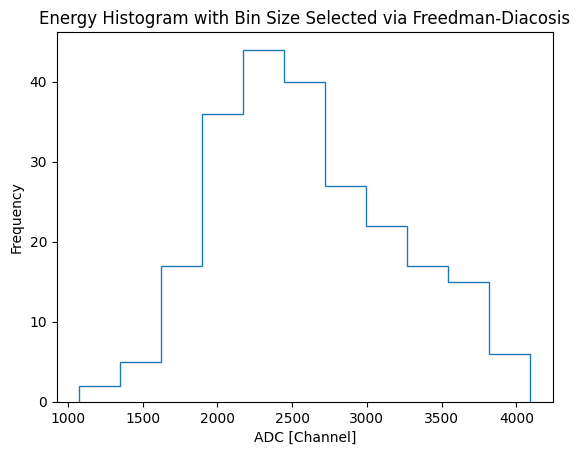

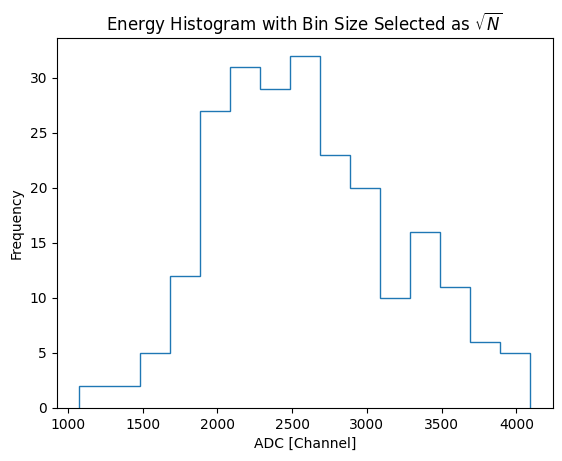

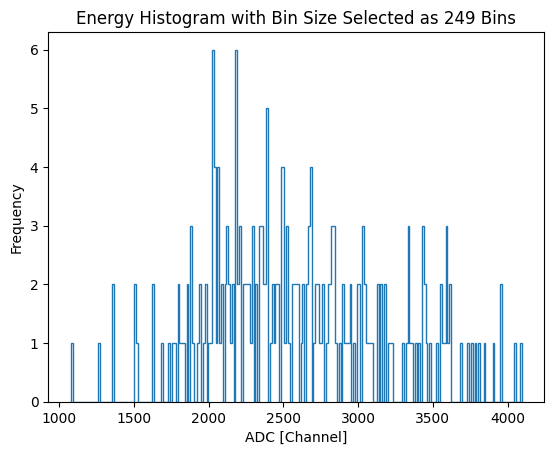

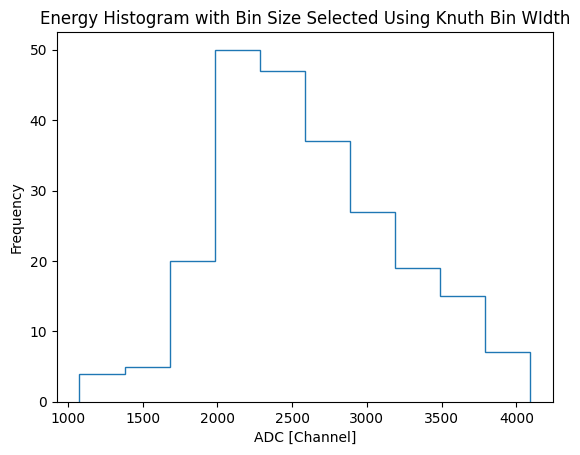

In [184]:
plt.title("Energy Histogram with Bin Size Selected via Freedman-Diacosis")
plt.xlabel("ADC [Channel]")
plt.ylabel("Frequency")
plt.hist(energy,bins="fd",histtype="step")
plt.show()

plt.title(r"Energy Histogram with Bin Size Selected as $\sqrt{N}$")
plt.xlabel("ADC [Channel]")
plt.ylabel("Frequency")
plt.hist(energy,bins=round(np.sqrt(len(energy))),histtype="step")
plt.show()

plt.title("Energy Histogram with Bin Size Selected as 249 Bins")
plt.xlabel("ADC [Channel]")
plt.ylabel("Frequency")
plt.hist(energy,bins=249,histtype="step")
plt.show()

plt.title("Energy Histogram with Bin Size Selected Using Knuth Bin WIdth")
plt.xlabel("ADC [Channel]")
plt.ylabel("Frequency")
plt.hist(energy,bins=n_bins_knuth(energy),histtype="step")
plt.show()

(np.float64(0.7318296008349348), np.float64(2236.4695950668015), np.float64(489.9984039475936))


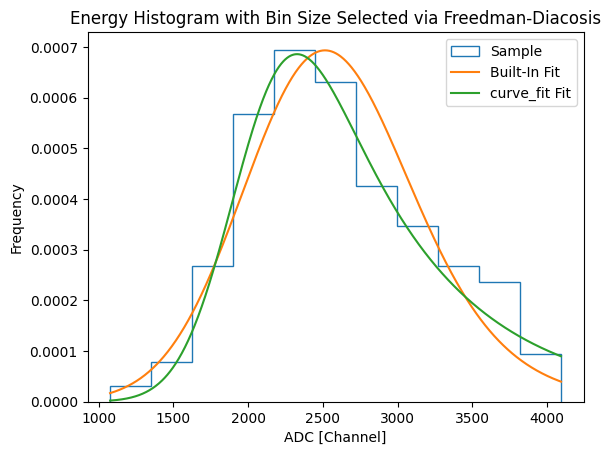

Chi-squared per ndof: 0.56


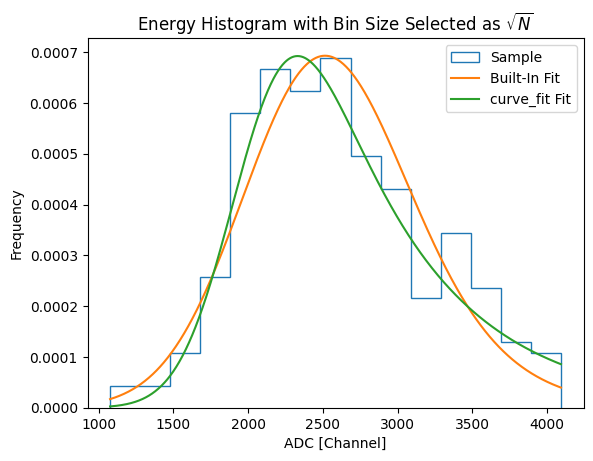

Chi-squared per ndof: 0.97


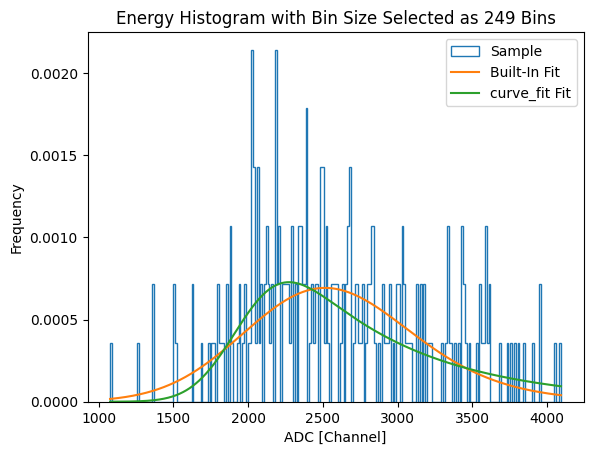

Chi-squared per ndof: 8.38


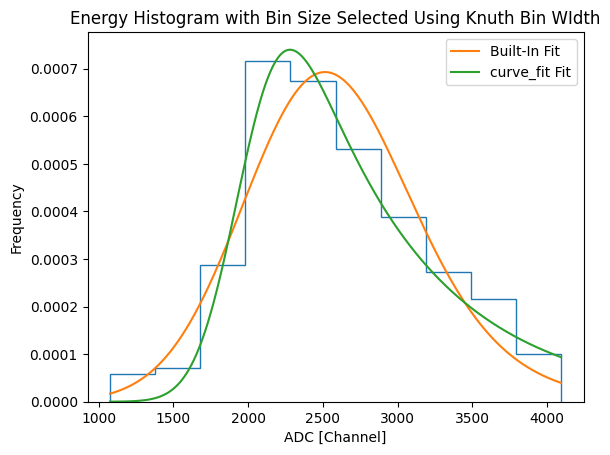

Chi-squared per ndof: 11.55


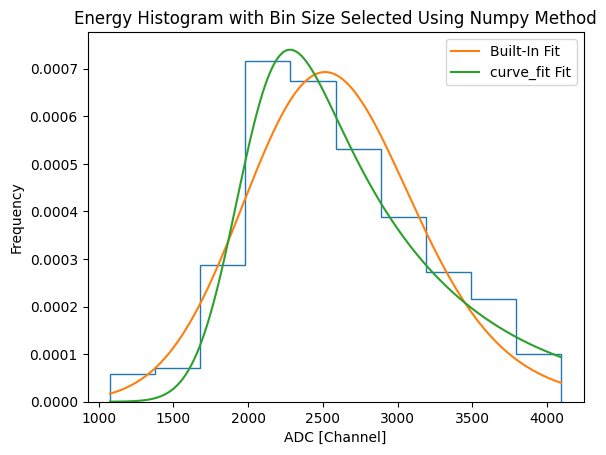

Chi-squared per ndof: 11.55


In [185]:
xfit = np.linspace(np.min(energy),np.max(energy),1000)

params = exponnorm.fit(energy,loc=1000,scale=1)
print(params)
yfit_rv = exponnorm.pdf(xfit,*params)

xfit_cf = np.linspace(np.min(energy),np.max(energy),1000)

plt.title("Energy Histogram with Bin Size Selected via Freedman-Diacosis")
plt.xlabel("ADC [Channel]")
plt.ylabel("Frequency")
_,bins,_ = plt.hist(energy,bins="fd",histtype="step",label="Sample",density=True)
n_bins = len(bins)-1
yfit_cf = exponnorm.pdf(xfit,*exp_mod_gauss_fit(energy,n_bins)[0::2])
plt.plot(xfit,yfit_rv,label="Built-In Fit")
plt.plot(xfit,yfit_cf,label="curve_fit Fit")
plt.legend()
plt.show()

fit_cdf = make_interp_spline(xfit,pdf2cdf(xfit,yfit_cf),5)
print(f"Chi-squared per ndof: {chi_squared_per_ndof(energy,n_bins,fit_cdf,n_params=3)[0]:.2f}")

plt.title(r"Energy Histogram with Bin Size Selected as $\sqrt{N}$")
plt.xlabel("ADC [Channel]")
plt.ylabel("Frequency")
_,bins,_ = plt.hist(energy,bins=round(np.sqrt(len(energy))),histtype="step",label="Sample",density=True)
n_bins = len(bins)-1
yfit_cf = exponnorm.pdf(xfit,*exp_mod_gauss_fit(energy,n_bins)[0::2])
plt.plot(xfit,yfit_rv,label="Built-In Fit")
plt.plot(xfit,yfit_cf,label="curve_fit Fit")
plt.legend()
plt.show()

fit_cdf = make_interp_spline(xfit,pdf2cdf(xfit,yfit_cf),5)
print(f"Chi-squared per ndof: {chi_squared_per_ndof(energy,n_bins,fit_cdf,n_params=3)[0]:.2f}")

plt.title("Energy Histogram with Bin Size Selected as 249 Bins")
plt.xlabel("ADC [Channel]")
plt.ylabel("Frequency")
_,bins,_ = plt.hist(energy,bins=249,histtype="step",label="Sample",density=True)
n_bins = len(bins)-1
yfit_cf = exponnorm.pdf(xfit,*exp_mod_gauss_fit(energy,n_bins)[0::2])
plt.plot(xfit,yfit_rv,label="Built-In Fit")
plt.plot(xfit,yfit_cf,label="curve_fit Fit")
plt.legend()
plt.show()

fit_cdf = make_interp_spline(xfit,pdf2cdf(xfit,yfit_cf),5)
print(f"Chi-squared per ndof: {chi_squared_per_ndof(energy,n_bins,fit_cdf,n_params=3)[0]:.2f}")

plt.title("Energy Histogram with Bin Size Selected Using Knuth Bin WIdth")
plt.xlabel("ADC [Channel]")
plt.ylabel("Frequency")
_,bins,_ = plt.hist(energy,bins=n_bins_knuth(energy),histtype="step",density=True)
n_bins = len(bins)-1
yfit_cf = exponnorm.pdf(xfit,*exp_mod_gauss_fit(energy,n_bins)[0::2])
plt.plot(xfit,yfit_rv,label="Built-In Fit")
plt.plot(xfit,yfit_cf,label="curve_fit Fit")
plt.legend()
plt.show()

fit_cdf = make_interp_spline(xfit,pdf2cdf(xfit,yfit_cf),5)
print(f"Chi-squared per ndof: {chi_squared_per_ndof(energy,n_bins,fit_cdf,n_params=3)[0]:.2f}")

plt.title("Energy Histogram with Bin Size Selected Using Numpy Method")
plt.xlabel("ADC [Channel]")
plt.ylabel("Frequency")
_,bins,_ = plt.hist(energy,bins=n_bins_np(energy),histtype="step",density=True)
n_bins = len(bins)-1
yfit_cf = exponnorm.pdf(xfit,*exp_mod_gauss_fit(energy,n_bins)[0::2])
plt.plot(xfit,yfit_rv,label="Built-In Fit")
plt.plot(xfit,yfit_cf,label="curve_fit Fit")
plt.legend()
plt.show()

fit_cdf = make_interp_spline(xfit,pdf2cdf(xfit,yfit_cf),5)
print(f"Chi-squared per ndof: {chi_squared_per_ndof(energy,n_bins,fit_cdf,n_params=3)[0]:.2f}")

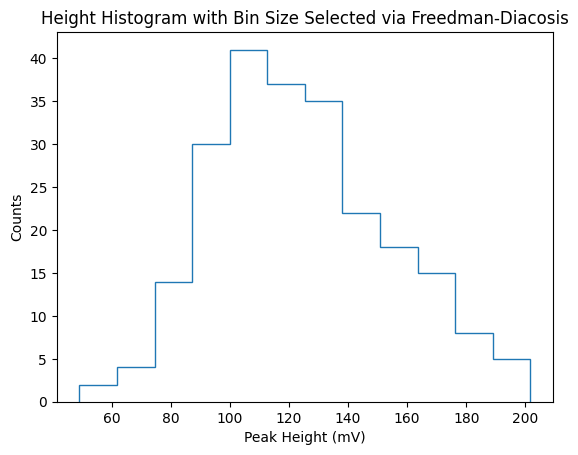

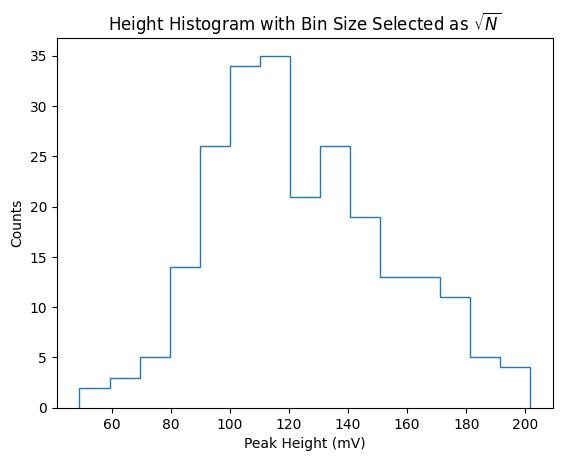

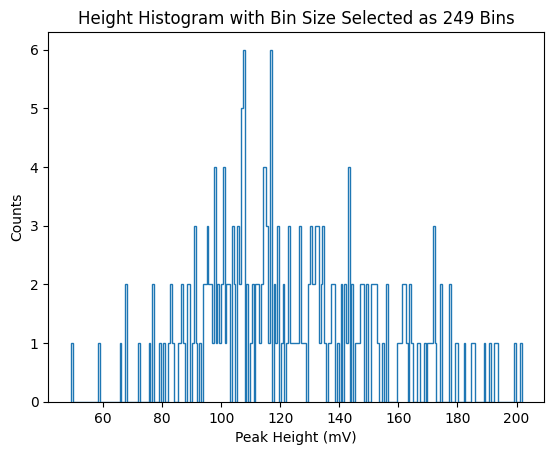

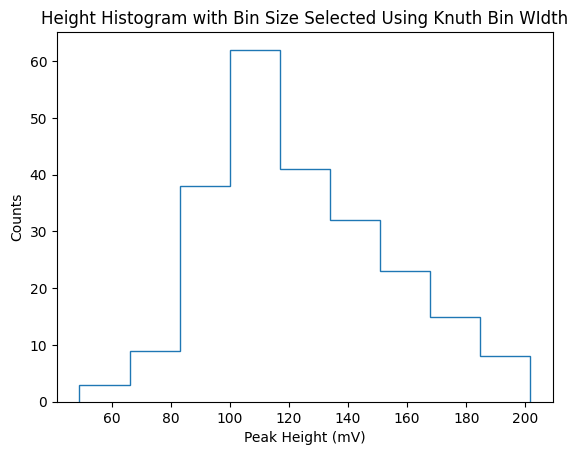

In [186]:
plt.title("Height Histogram with Bin Size Selected via Freedman-Diacosis")
plt.xlabel("Peak Height (mV)")
plt.ylabel("Counts")
plt.hist(height,bins="fd",histtype="step")
plt.show()

plt.title(r"Height Histogram with Bin Size Selected as $\sqrt{N}$")
plt.xlabel("Peak Height (mV)")
plt.ylabel("Counts")
plt.hist(height,bins=round(np.sqrt(len(height))),histtype="step")
plt.show()

plt.title("Height Histogram with Bin Size Selected as 249 Bins")
plt.xlabel("Peak Height (mV)")
plt.ylabel("Counts")
plt.hist(height,bins=249,histtype="step")
plt.show()

plt.title("Height Histogram with Bin Size Selected Using Knuth Bin WIdth")
plt.xlabel("Peak Height (mV)")
plt.ylabel("Counts")
plt.hist(height,bins=n_bins_knuth(height),histtype="step")
plt.show()

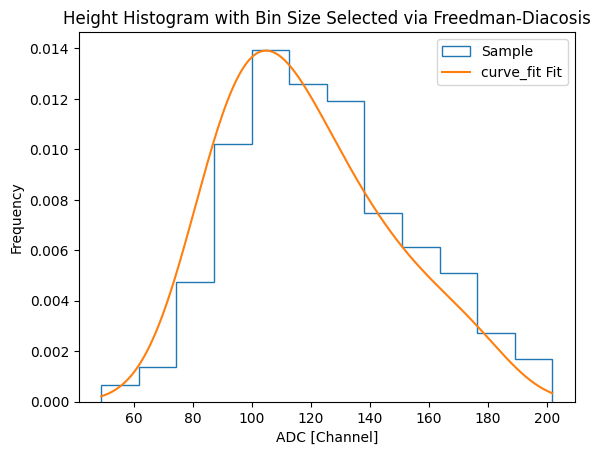

Chi-squared per ndof: 1.27


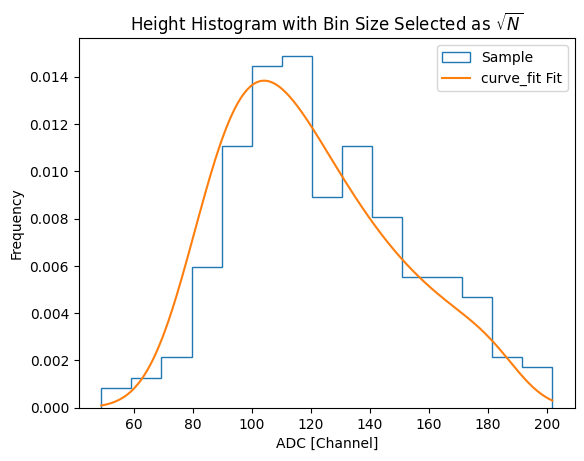

Chi-squared per ndof: 1.20


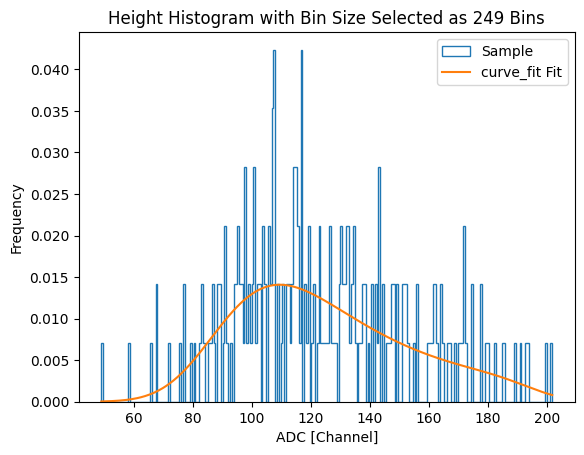

Chi-squared per ndof: 1.77


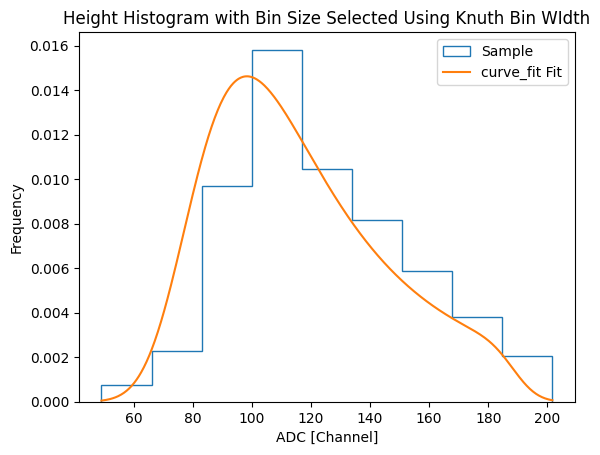

Chi-squared per ndof: 3.34


In [187]:
xfit = np.linspace(np.min(height),np.max(height),1000)

plt.title("Height Histogram with Bin Size Selected via Freedman-Diacosis")
plt.xlabel("ADC [Channel]")
plt.ylabel("Frequency")
_,bins,_ = plt.hist(height,bins="fd",histtype="step",label="Sample",density=True)
n_bins = len(bins)-1
yfit_cf = landau_star_gauss_fastest(*landau_star_gauss_fit_fastest(height,n_bins)[0::2],np.min(xfit),np.max(xfit))(xfit)
plt.plot(xfit,yfit_cf,label="curve_fit Fit")
plt.legend()
plt.show()

fit_cdf = make_interp_spline(xfit,pdf2cdf(xfit,yfit_cf),5)
print(f"Chi-squared per ndof: {chi_squared_per_ndof(height,n_bins,fit_cdf,n_params=3)[0]:.2f}")

plt.title(r"Height Histogram with Bin Size Selected as $\sqrt{N}$")
plt.xlabel("ADC [Channel]")
plt.ylabel("Frequency")
_,bins,_ = plt.hist(height,bins=round(np.sqrt(len(height))),histtype="step",label="Sample",density=True)
n_bins = len(bins)-1
yfit_cf = landau_star_gauss_fastest(*landau_star_gauss_fit_fastest(height,n_bins)[0::2],np.min(xfit),np.max(xfit))(xfit)
plt.plot(xfit,yfit_cf,label="curve_fit Fit")
plt.legend()
plt.show()

fit_cdf = make_interp_spline(xfit,pdf2cdf(xfit,yfit_cf),5)
print(f"Chi-squared per ndof: {chi_squared_per_ndof(height,n_bins,fit_cdf,n_params=3)[0]:.2f}")

plt.title("Height Histogram with Bin Size Selected as 249 Bins")
plt.xlabel("ADC [Channel]")
plt.ylabel("Frequency")
_,bins,_ = plt.hist(height,bins=249,histtype="step",label="Sample",density=True)
n_bins = len(bins)-1
yfit_cf = landau_star_gauss_fastest(*landau_star_gauss_fit_fastest(height,n_bins)[0::2],np.min(xfit),np.max(xfit))(xfit)
plt.plot(xfit,yfit_cf,label="curve_fit Fit")
plt.legend()
plt.show()

fit_cdf = make_interp_spline(xfit,pdf2cdf(xfit,yfit_cf),5)
print(f"Chi-squared per ndof: {chi_squared_per_ndof(height,n_bins,fit_cdf,n_params=3)[0]:.2f}")

plt.title("Height Histogram with Bin Size Selected Using Knuth Bin WIdth")
plt.xlabel("ADC [Channel]")
plt.ylabel("Frequency")
_,bins,_ = plt.hist(height,bins=n_bins_knuth(height),label="Sample",histtype="step",density=True)
n_bins = len(bins)-1
yfit_cf = landau_star_gauss_fastest(*landau_star_gauss_fit_fastest(height,n_bins)[0::2],np.min(xfit),np.max(xfit))(xfit)
plt.plot(xfit,yfit_cf,label="curve_fit Fit")
plt.legend()
plt.show()

fit_cdf = make_interp_spline(xfit,pdf2cdf(xfit,yfit_cf),5)
print(f"Chi-squared per ndof: {chi_squared_per_ndof(height,n_bins,fit_cdf,n_params=3)[0]:.2f}")